# Практика 3

In [39]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_breast_cancer 
from imblearn.datasets import make_imbalance 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score , recall_score, precision_score
from sklearn.preprocessing import StandardScaler


X , y = load_breast_cancer(return_X_y= True)
 

X , y = make_imbalance(X, y , sampling_strategy = {0: 50 ,1:200}, random_state= 42)

X_train, X_test , y_train ,y_test = train_test_split(X, y, test_size = 0.3, random_state = 42 , stratify = y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

log_reg = LogisticRegression(random_state = 42)
log_reg.fit(X_train_scaled, y_train)

rf_clf = RandomForestClassifier(random_state = 42)
rf_clf.fit(X_train, y_train)


model = { 
    'LOgistic Regression' : (log_reg , X_test_scaled),
    'RandomForest' : (rf_clf, X_test)
}

result = []

for name, (model, X_data) in model.items():
    y_pred = model.predict(X_data)
    result.append({
        'Model' : name, 
        'Accuracy': accuracy_score(y_test, y_pred), 
        'Precision' : precision_score(y_test, y_pred),
        'Recall' : recall_score(y_test, y_pred), 
        'F1_score' : f1_score(y_test, y_pred)
    })
    

print('Результат диспабанса классов: (0: 50 , 1: 200):')
print(pd.DataFrame(result))

Результат диспабанса классов: (0: 50 , 1: 200):
                 Model  Accuracy  Precision    Recall  F1_score
0  LOgistic Regression  0.986667   0.983607  1.000000  0.991736
1         RandomForest  0.946667   0.966667  0.966667  0.966667


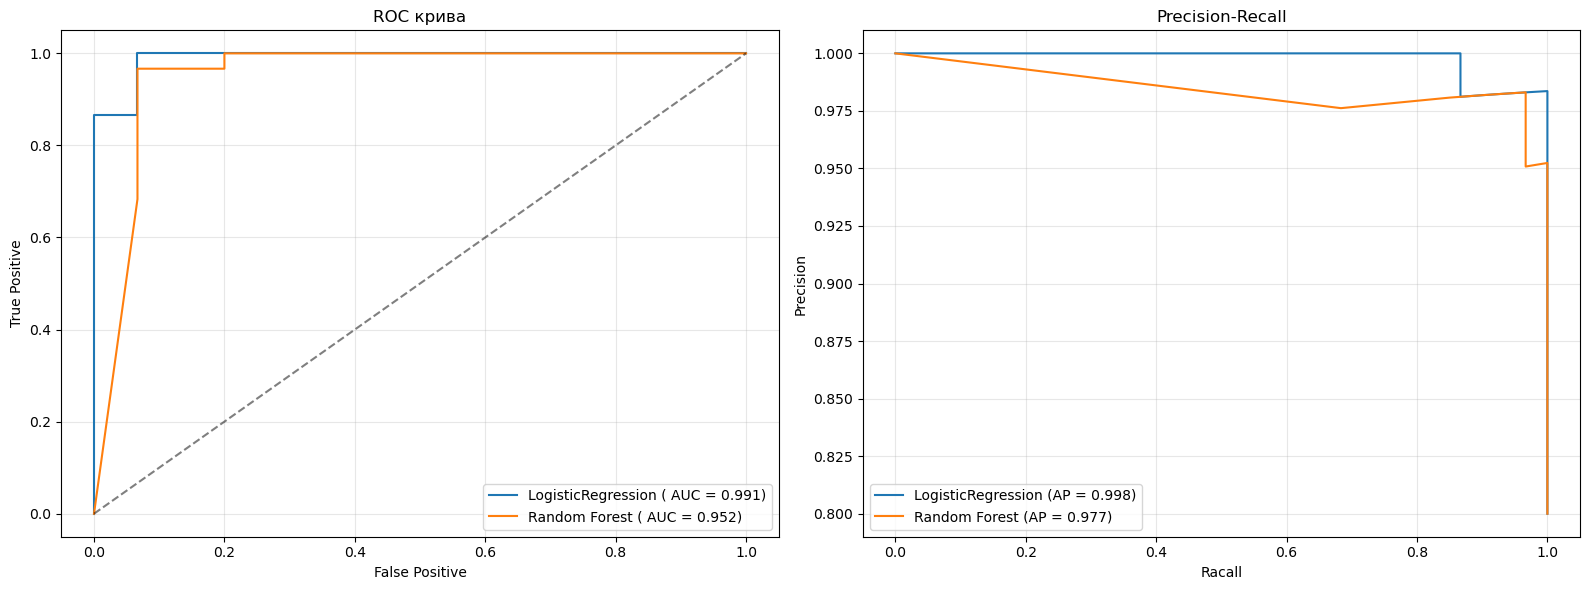

In [72]:
import matplotlib.pyplot as plt 
from sklearn.metrics import roc_curve , auc, precision_recall_curve , average_precision_score


y_probs_lr = log_reg.predict_proba(X_test_scaler)[:,1]
y_probs_rn = rn_for.predict_proba(X_test)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for probs, name in zip([y_probs_lr , y_probs_rn] , ['LogisticRegression' , 'Random Forest']):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax1.plot(fpr, tpr, label = f'{name} ( AUC = {roc_auc:.3f})')


ax1.plot([0,1], [0,1] , 'k--' , alpha = 0.5)
ax1.set_xlabel('False Positive')
ax1.set_ylabel('True Positive')
ax1.set_title('ROC крива')
ax1.legend()
ax1.grid(alpha = 0.3)


for probs , name  in zip([y_probs_lr,y_probs_rn ], ['LogisticRegression' , 'Random Forest']):
    precision, recall , _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax2.plot(recall, precision , label = f'{name} (AP = {ap:.3f})' )


ax2.set_xlabel('Racall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall')
ax2.legend()
ax2.grid(alpha = 0.3)

plt.tight_layout()
plt.show()



In [86]:
lambda_fn = 5
lambda_fp = 1
p_pos = 0.3
p_neg = 0.7


probs = y_probs_lr


thresholds = np.linspace(0,1,100)

losses = []

for t in thresholds:
    y_pred_t = (probs >= t).astype(int) 


    fp = np.sum((y_pred_t == 1) & (y_test == 0))
    fn = np.sum((y_pred_t == 0) & (y_test ==1 )) 

    loss = (lambda_fp * fp * p_neg) + (lambda_fn  * fn* p_pos) 
    losses.append(loss) 


best_thresholds = thresholds[np.argmin(losses)]

print(f'Оптимальный порог : {best_thresholds:.4f}')

Оптимальный порог : 0.2525


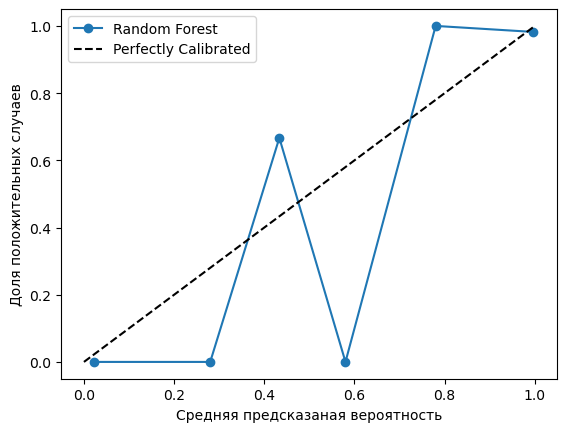

Brier Score до калибровки: 0.0326
Brier Score после калибровки: 0.0327


In [96]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss


prob_true, prob_pred = calibration_curve(y_test, y_probs_rn, n_bins = 8) 

plt.plot(prob_pred, prob_true , marker = 'o', label = 'Random Forest')
plt.plot([0,1] , [0,1], 'k--', label = "Perfectly Calibrated")
plt.xlabel('Средняя предсказаная вероятность')
plt.ylabel('Доля положительных случаев')
plt.legend()
plt.show()


calibrated_rf = CalibratedClassifierCV(rn_for, method='sigmoid', cv='prefit')
calibrated_rf.fit(X_test, y_test)
y_probs_calibrated = calibrated_rf.predict_proba(X_test)[:, 1]

bs_before = brier_score_loss(y_test, y_probs_rn)
bs_after = brier_score_loss(y_test, y_probs_calibrated)

print(f"Brier Score до калибровки: {bs_before:.4f}")
print(f"Brier Score после калибровки: {bs_after:.4f}")